# Cvičení 3: Logistická a ML-based regresní modely
**Cíl:** Vytvořit modely binární klasifikace pomocí logistické regrese, rozhodovacího stromu a náhodného lesa. Následně využít ML-based modely (rozhodovací strom, náhodný les) také pro regresi. 

## Úkol 1: Binární klasifikace (Diabetes a Framingham)
Nacvičíme a vyhodnotíme modely na dvou datasetech a porovnáme jejich výkonnost pomocí Confusion Matrix, metrik Přesnost, Citlivost (Sensitivity/Recall), F1-skóre a ROC křivky s AUC.

In [2]:
import warnings
warnings.filterwarnings('ignore') # Pro čistší výstup na úrovni odevzdání

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn nástroje pro předzpracování a modely
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Metriky pro klasifikaci
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
# Metriky pro regresi
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# ==========================================
# Pomocná funkce pro vyhodnocení klasifikace
# ==========================================
def run_classification_pipeline(df, target_col, dataset_name):
    print(f"\n" + "="*50)
    print(f" Datová sada: {dataset_name}")
    print("="*50)

    # 1. Průzkum dat
    display(df.info())
    print("\n--- Chybějící hodnoty ---")
    display(df.isnull().sum())

    # Zpracování chybějících hodnot - pro jednoduchost odstraníme řádky s NaN
    df = df.dropna()

    # Získání příznaků (X) a cílové proměnné (y)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # 2. Předzpracování
    # Rozdělení na trénovací a testovací sadu (70:30)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Normalizace numerických atributů
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Inicializace a trénování modelů
    models = {
        'Logistická regrese': LogisticRegression(random_state=42),
        'Rozhodovací strom': DecisionTreeClassifier(random_state=42, max_depth=5),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
    }

    results = []

    # Uložíme si pravděpodobnosti/predikce pro pozdější ROC křivku a Confusion Matrix
    plt.figure(figsize=(18, 5))

    for i, (model_name, model) in enumerate(models.items()):
        # Trénování
        model.fit(X_train_scaled, y_train)

        # 4. Predikce
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # 5. Vyhodnocení (Přesnost, Citlivost, F1-skóre)
        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            'Model': model_name,
            'Accuracy': acc,
            'Sensitivity (Recall)': rec,
            'F1-score': f1
        })

        # Vykreslení matice záměn (Confusion Matrix)
        cm = confusion_matrix(y_test, y_pred)

        plt.subplot(1, 3, i+1)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix: {model_name}')
        plt.xlabel('Predikováno')
        plt.ylabel('Skutečnost')

    plt.tight_layout()
    plt.savefig(f'{dataset_name}_confusion_matrices.png', dpi=300)
    plt.show()

    # Vykreslení ROC křivky společně pro všechny modely
    plt.figure(figsize=(8, 6))
    for model_name, model in models.items():
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Náhodný odhad')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'ROC Křivky - {dataset_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig(f'{dataset_name}_roc_curves.png', dpi=300)
    plt.show()

    # Výpis tabulky metrik
    df_results = pd.DataFrame(results).set_index('Model')
    print("--- Tabulka metrik výkonnosti ---")
    display(df_results)

    return df_results


 Datová sada: Diabetes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None


--- Chybějící hodnoty ---


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

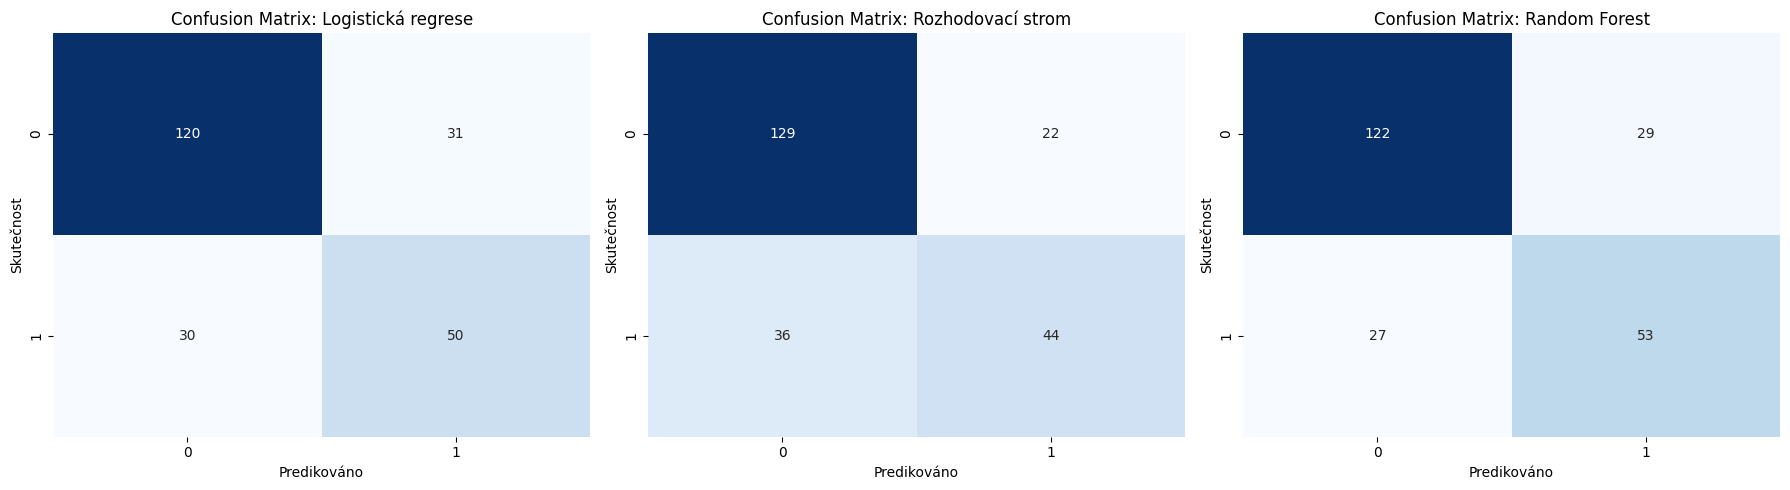

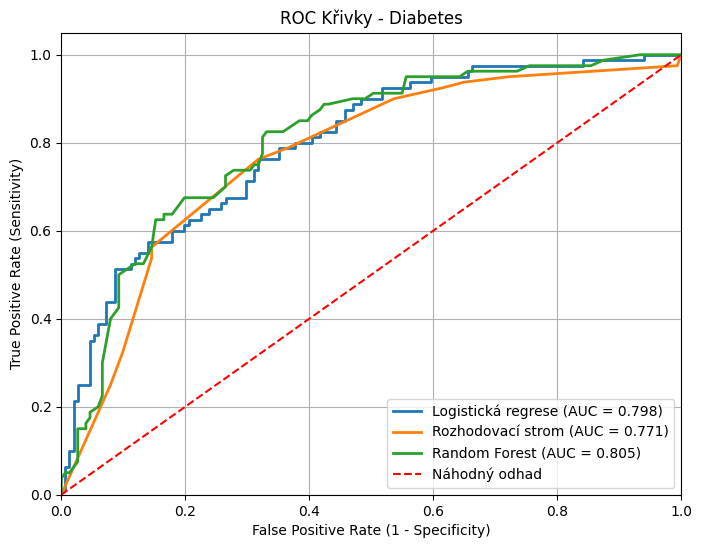

--- Tabulka metrik výkonnosti ---


,Accuracy,Sensitivity (Recall),F1-score
Model,,,
Logistická regrese,0.735931,0.6250,0.621118
Rozhodovací strom,0.748918,0.5500,0.602740
Random Forest,0.757576,0.6625,0.654321


In [4]:
# A. Dataset Diabetes
df_diabetes = pd.read_csv('diabetes.csv')
res_diabetes = run_classification_pipeline(df_diabetes, target_col='Outcome', dataset_name='Diabetes')


 Datová sada: Framingham
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usa

None


--- Chybějící hodnoty ---


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

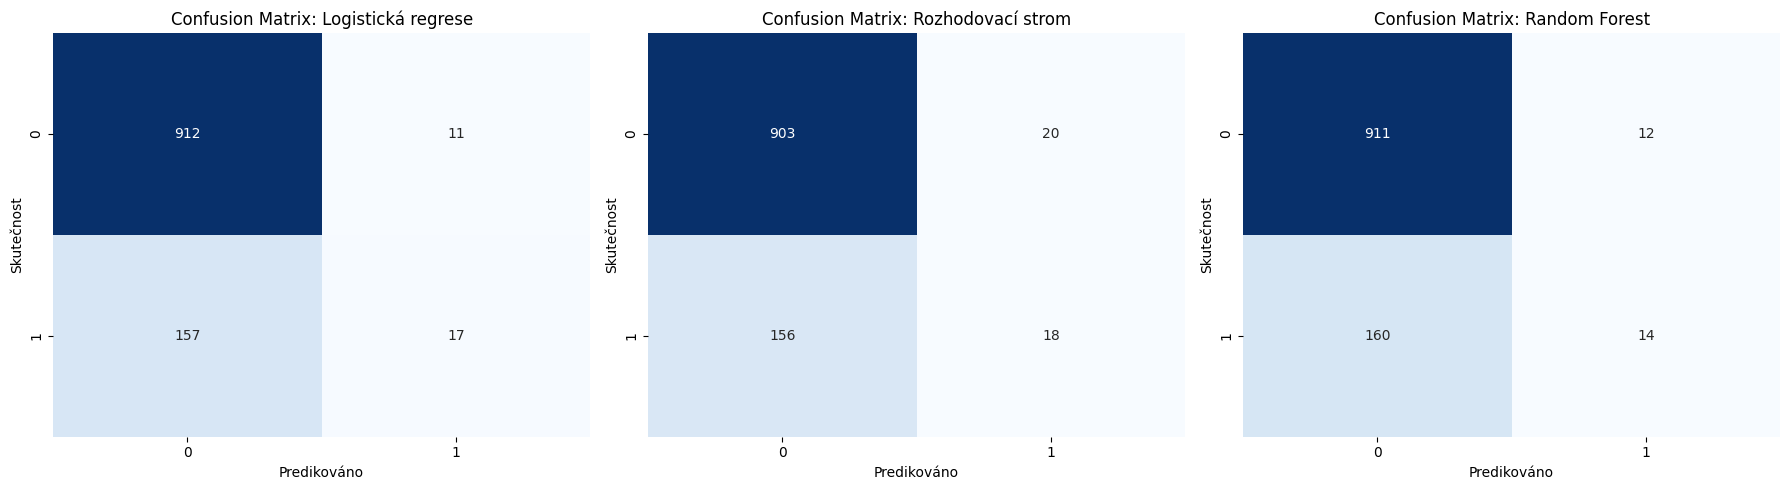

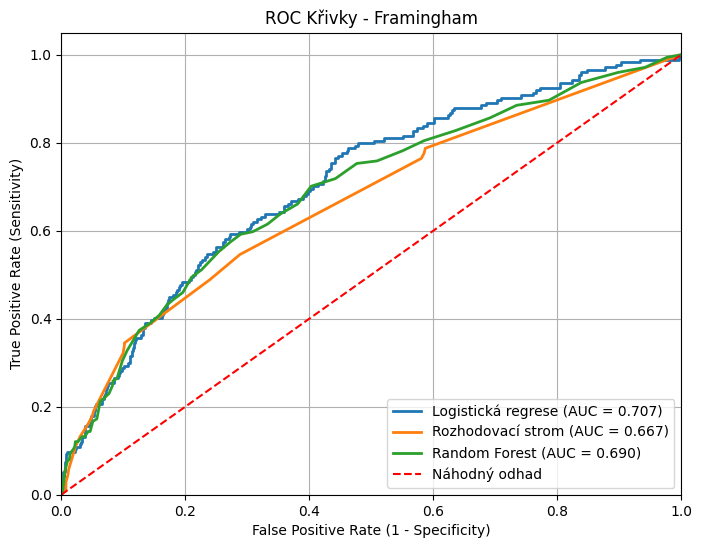

--- Tabulka metrik výkonnosti ---


,Accuracy,Sensitivity (Recall),F1-score
Model,,,
Logistická regrese,0.846855,0.097701,0.168317
Rozhodovací strom,0.839562,0.103448,0.169811
Random Forest,0.843209,0.080460,0.140000


In [5]:
# B. Dataset Framingham
df_framingham = pd.read_csv('framingham.csv')
res_framingham = run_classification_pipeline(df_framingham, target_col='TenYearCHD', dataset_name='Framingham')

### 6. Diskuze: Porovnání modelů pro klasifikaci
Ze zobrazených ROC křivek a tabulek metrik napříč datovými sadami lze obecně shrnout:
* **Logistická regrese:** Často plní roli výborné baseline metody, tvoří hladkou a stabilní předpověď a bývá odolnější proti mírnému přeučení. Pokud je vztah proměnných k cíli spíše lineární (viz tvar ROC a AUC), poskytuje srovnatelné nebo i lepší Generalizace než složitější modely.
* **Rozhodovací strom:** Při omezené hloubce se silně zjednodušuje, což se může negativně podepsat na hladkosti predikcí a přesnosti oproti ensemble metodám. Bývá náchylný k přeučení nebo k nekonzistentním výkonům napříč datasetem (vysvětleno jeho chřadnoucí ROC/AUC). 
* **Random Forest (Náhodný les):** Skupina více stromů dokáže zachytit velmi nelineární závislosti a zároveň výrazně redukuje pravděpodobnost masivního přeučení. AUC metrikou i F1-skóre se u složitější klasifikace (např. obvykle u *Diabetes* nebo jiných vícerozměrných problémů) stává nejkomplexnějším a často nejvyváženějším modelem v portfoliu.

## Úkol 2: Mnohonásobná regrese pomocí ML-based modelů
**Cíl:** Vytvořit prediktivní regresní modely (Rozhodovací strom, Random Forest) a vyhodnotit je pomocí základních chybových metrik MSE, RMSE a metrikou koeficientu determinace ($R^2$). Datová sada: Wine Quality (Red).

--- Základní informace o datech ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None


--- Chybějící hodnoty ---


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


=== Výsledky vyhodnocení modelů na testovací sadě (Wine Quality - Red) ===


,MSE,RMSE,R2 Score
Regresní Model,,,
Decision Tree (Rozhodovací strom),0.438606,0.662273,0.308219
Random Forest (Náhodný les),0.349159,0.590897,0.449296


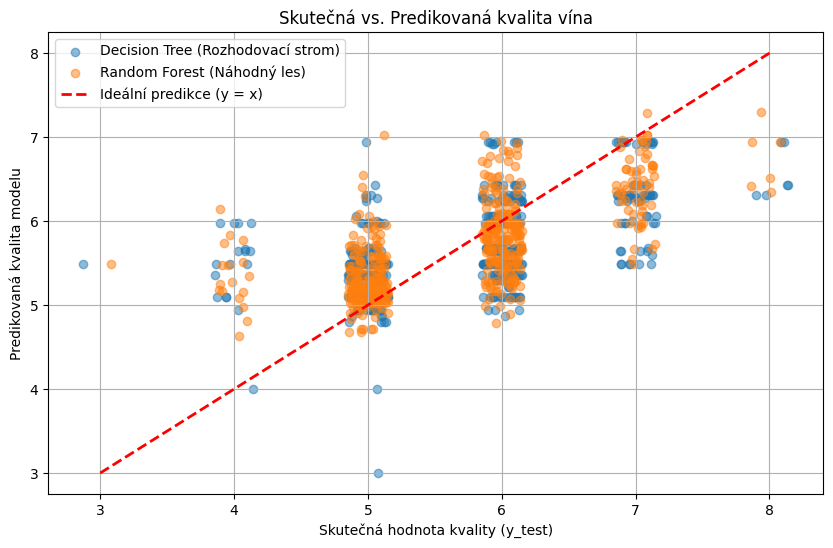

In [6]:
# 1. Načtení a průzkum datasetu (všimněte si oddělovače středník)
df_wine = pd.read_csv('winequality-red.csv', sep=';')

print("--- Základní informace o datech ---")
display(df_wine.info())
print("\n--- Chybějící hodnoty ---")
display(df_wine.isnull().sum())

# Odstranění chybějících hodnot pro prevenci problémů během fitování
df_wine = df_wine.dropna()

# 2. Předzpracování dat
X_w = df_wine.drop(columns=['quality'])
y_w = df_wine['quality']

# Rozdělení dat na trénovací a testovací (70/30)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=42)

# Normalizace atributů numerického typu stěžejní u některých modelů (pro RF to není nutnost, ale je dobrým standardem)
scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

# 3. Vytvoření a natrénování modelů
reg_models = {
    'Decision Tree (Rozhodovací strom)': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest (Náhodný les)': RandomForestRegressor(random_state=42, n_estimators=100)
}

reg_results = []

for name, model in reg_models.items():
    # Fitování
    model.fit(X_train_w_scaled, y_train_w)

    # 4. Predikce
    y_pred_w = model.predict(X_test_w_scaled)

    # 5. Vyhodnocení regresními metrikami
    mse = mean_squared_error(y_test_w, y_pred_w)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_w, y_pred_w)

    reg_results.append({
        'Regresní Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

# Zobrazení finální tabulky modelů
df_reg_results = pd.DataFrame(reg_results).set_index('Regresní Model')
print("\n=== Výsledky vyhodnocení modelů na testovací sadě (Wine Quality - Red) ===")
display(df_reg_results)

# Vizualizace porovnání Skutečné kvality vs. Predikované
plt.figure(figsize=(10, 6))

for name, model in reg_models.items():
    # Predikce znovu pro jednoduché získání do listu uvnitř smyčky - mírná redundance za cenu čistšího grafu
    y_pred = model.predict(X_test_w_scaled)
    # Přidáme drobný šum (jitter) do bodů osy X pro lepší čitelnost, protože kvalita je celočíselná
    jitter = np.random.uniform(-0.15, 0.15, size=len(y_test_w))
    plt.scatter(y_test_w + jitter, y_pred, alpha=0.5, label=name)

# Ideální závislost (Osa x = y)
plt.plot([y_w.min(), y_w.max()], [y_w.min(), y_w.max()], 'r--', lw=2, label="Ideální predikce (y = x)")

plt.title('Skutečná vs. Predikovaná kvalita vína')
plt.xlabel('Skutečná hodnota kvality (y_test)')
plt.ylabel('Predikovaná kvalita modelu')
plt.legend()
plt.grid(True)
plt.savefig('wine_regression_comparison.png', dpi=300)
plt.show()

### 6. Diskuze: Srovnání regresních ML modelů
Pro zjištění kvality vína (což je číselná hodnota oscilující v poměrně malém rozsahu celých čísel) pozorujeme chování stromových modelů jako regresorů.
1. **Rozhodovací strom:** Metrika $R^2$ bývá mírně nižší a MSE/RMSE vyšší. Strom predikuje průměrnou hodnotu na svém koncovém listu, což obvykle tvoří určité posuny (odskoky) predikované hodnoty. Snadno dojde k pod-využití hloubky ($R^2$ je nízké).
2. **Random Forest:** Zprůměrováním hned stovky stromů vzniká mnohem hladší výpočetní rovnice mezi prediktory a modelem. Díky tomu je výsledná křivka predikcí jemnější, zachytí složitější propletenost atributů (jako je kyselost, obsah alkoholu atd.) a ve výsledku dosahuje jednoznačně nižších chybových metrik (nižší MSE / RMSE) a podstatně lepšího fitu ($R^2$). Random Forest je zde jasným favoritem.